# AirNow and UFS-CHEM

Our first example will demonstrate the basics available in MELODIES MONET to 
compare the meteorological capabilities of UFS-CHEM results against AirNow surface observations. We will analyze variables including temperature, dewpoint, windspeed, and wind direction.

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "control_ufschem-example.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2017-07-01-00:00:00',
  'end_time': '2017-07-02-00:00:00',
  'output_dir': './output_img/ufschem',
  'debug': True},
 'model': {'ufschem_v1': {'files': '/wrk/d2/rschwantes/UFS-Chem_v1/outdir_UFS_C96_CATChem_AM4GAS/short/2017_07_01_03_ufschemv1.nc',
   'mod_type': 'ufschem',
   'mod_kwargs': {'surf_only': True},
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'specific_hum': 'spfh'},
    'rel_hum': {'specific_hum': 'spfh'},
    'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'wind_barb': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
   'mapping': {'airnow': {'o3': 'OZONE',
     'temperature_k': 'TEMP',
     'windspeed': 'WS',
     'winddir': 'WD',
     'rel_hum': 'RHUM'}},
   'projection': None,
   'plot_kwargs': {'color': 'magenta', 'marker': 's', 'linestyle': '-'}}},
 'obs': {'airnow': {'use_airnow': True,
   'filename': '/home/lthompson/obs/airnow/AirNow_20170701_20170704.nc',
   'obs_t

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='control_ufschem-example.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2017-07-01 00:00:00'),
    end_time=Timestamp('2017-07-02 00:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output_img/ufschem',
    output_dir_save='./output_img/ufschem',
    output_dir_read='./output_img/ufschem',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

ufschem
/wrk/d2/rschwantes/UFS-Chem_v1/outdir_UFS_C96_CATChem_AM4GAS/short/2017_07_01_03_ufschemv1.nc
**** Reading UFS-CHEM model output...
Performing extra calculations...
Calculating Dewpoint...
Calculating relative humidity...
Calculating windpseed...
Calculating wind direction...
Calculating wind barbs...


Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [7]:
an.models['ufschem_v1'].obj

<xarray.Dataset> Size: 362MB
Dimensions:        (time: 72, z: 1, y: 192, x: 384)
Coordinates:
    latitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude      (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time           (time) datetime64[ns] 576B 2017-07-01T01:00:00 ... 2017-07-04
Dimensions without coordinates: z, y, x
Data variables: (12/14)
    spfh           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    o3             (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k  (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa    (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...             ...
    dz_m           (time, z, y, x) float32 21MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    pres_pa_mid    (time, z, y, x) float32 21MB 37.92 37.92 ... 37.92 37.92
    dewpoint       (time, z, y, x) float64 42MB 271.7 271.7 ... 217.3 217.2
    rel_hum        (time, z, y, x) float64 42MB 94.35 94.35 ... 66.12 66.08
    windspeed      (time, z, y, x) float64 42MB 6.511 6.511 6.511 ... 6.09 6.085
    winddir        (time, z, y, x) float32 21MB 203.4 202.6 ... 99.82 100.6
Attributes:
    ak:           [2.0000000e+01 6.4247000e+01 1.3779000e+02 2.2195800e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    history:      Wed Jun 25 09:54:47 2025: ncrcat 20170701_dynf001.nc 201707...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [8]:
an.open_obs()

In [9]:
an.obs

{'airnow': observation(
     obs='airnow',
     label='airnow',
     file='/home/lthompson/obs/airnow/AirNow_20170701_20170704.nc',
     obj=...,
     type='pt_src',
     sat_type=None,
     data_proc=None,
     variable_dict={'OZONE': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Ozone (ppbv)', 'xlabel_plot': 'Ozone (ppbv)', 'vmin_plot': 15.0, 'vmax_plot': 60, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'TEMP': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -1.0, 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'vmin_plot': 275, 'vmax_plot': 320, 'vdiff_plot': 20.0, 'nlevels_plot': 21}, 'WS': {'unit_scale': 1, 'nan_value': -1.0, 'ylabel_plot': 'Windspeed (m/s)', 'xlabel_plot': 'Windspeed (m/s)', 'vmin_plot': 0, 'vmax_plot': 10, 'vdiff_plot': 4, 'nlevels_plot': 18}, 'WD': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -1.0, 'ylabel_plot': 'Wind Direction (deg)', 'xlabel_plot': 'Wind Direction (deg)', 'vmin_plot':

In [10]:
an.obs['airnow'].obj

<xarray.Dataset> Size: 27MB
Dimensions:     (time: 73, y: 1, x: 1942)
Coordinates:
  * time        (time) datetime64[ns] 584B 2017-07-01 ... 2017-07-04
    siteid      (x) <U9 70kB ...
    latitude    (x) float64 16kB ...
    longitude   (x) float64 16kB ...
  * x           (x) int64 16kB 0 1 2 3 4 5 6 ... 1936 1937 1938 1939 1940 1941
Dimensions without coordinates: y
Data variables: (12/30)
    BARPR       (time, y, x) float64 1MB ...
    BC          (time, y, x) float64 1MB ...
    CO          (time, y, x) float64 1MB ...
    NO          (time, y, x) float64 1MB ...
    NO2         (time, y, x) float64 1MB ...
    NO2Y        (time, y, x) float64 1MB ...
    ...          ...
    utcoffset   (y, x) int64 16kB ...
    cmsa_name   (y, x) float64 16kB ...
    msa_code    (y, x) float64 16kB ...
    msa_name    (y, x) <U52 404kB ...
    state_name  (y, x) <U2 16kB ...
    epa_region  (y, x) <U5 39kB ...
Attributes:
    title:         
    format:        NetCDF-4
    date_created:  2025-05-29

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [11]:
%%time

an.pair_data()

1, in pair data
After pairing:               time  BARPR   BC   CO            NO           NO2  NO2Y  NOX  \
0      2017-07-01   -1.0 -1.0 -1.0 -1.000000e+00 -1.000000e+00  -1.0 -1.0   
1      2017-07-01   -1.0 -1.0 -1.0  3.094320e-08  1.000000e+00  -1.0 -1.0   
2      2017-07-01   -1.0 -1.0 -1.0  3.094320e-08  1.000000e+00  -1.0 -1.0   
3      2017-07-01   -1.0 -1.0 -1.0  3.094320e-08  5.820766e-09  -1.0 -1.0   
4      2017-07-01   -1.0 -1.0 -1.0  1.000000e+00 -1.000000e+00  -1.0 -1.0   
...           ...    ...  ...  ...           ...           ...   ...  ...   
141761 2017-07-04   -1.0 -1.0 -1.0 -1.000000e+00 -1.000000e+00  -1.0 -1.0   
141762 2017-07-04   -1.0 -1.0 -1.0 -1.000000e+00 -1.000000e+00  -1.0 -1.0   
141763 2017-07-04   -1.0 -1.0 -1.0 -1.000000e+00 -1.000000e+00  -1.0 -1.0   
141764 2017-07-04   -1.0 -1.0 -1.0 -1.000000e+00 -1.000000e+00  -1.0 -1.0   
141765 2017-07-04   -1.0 -1.0 -1.0 -1.000000e+00 -1.000000e+00  -1.0 -1.0   

        NOY   OC  ...  state_name  epa_regi

In [12]:
an.paired

{'airnow_ufschem_v1': pair(
     type='pt_sfc',
     radius_of_influence=1000000.0,
     obs='airnow',
     model='ufschem_v1',
     model_vars=['o3', 'temperature_k', 'windspeed', 'winddir', 'rel_hum'],
     obs_vars=['OZONE', 'TEMP', 'WS', 'WD', 'RHUM'],
     filename='airnow_ufschem_v1.nc',
 )}

In [13]:
an.paired['airnow_ufschem_v1']

pair(
    type='pt_sfc',
    radius_of_influence=1000000.0,
    obs='airnow',
    model='ufschem_v1',
    model_vars=['o3', 'temperature_k', 'windspeed', 'winddir', 'rel_hum'],
    obs_vars=['OZONE', 'TEMP', 'WS', 'WD', 'RHUM'],
    filename='airnow_ufschem_v1.nc',
)

## MELODIES-MONET now contains several meteorological capabilities 

In addition to previous capabilites and plots, users can now:

* Specify wind barbs
    * Note: users may experience longer wait times if they wish to plot wind barbs
* Create rose plots for pollution and wind speed
    * Rose plots can be aggregated across scales (e.g. EPA region and CONUS)
* Create boxplots on given intervals for any of the supported meteorological variables 
* Mark statistical significance on boxplots


## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
Wind barbs may take longer to plot... Please be patient.
[1.5107726879915507e-05]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

airnow vs. ufschem_v1: Custom statistical test, P_val:1.511e-05
[8.318334355807609e-11]
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.

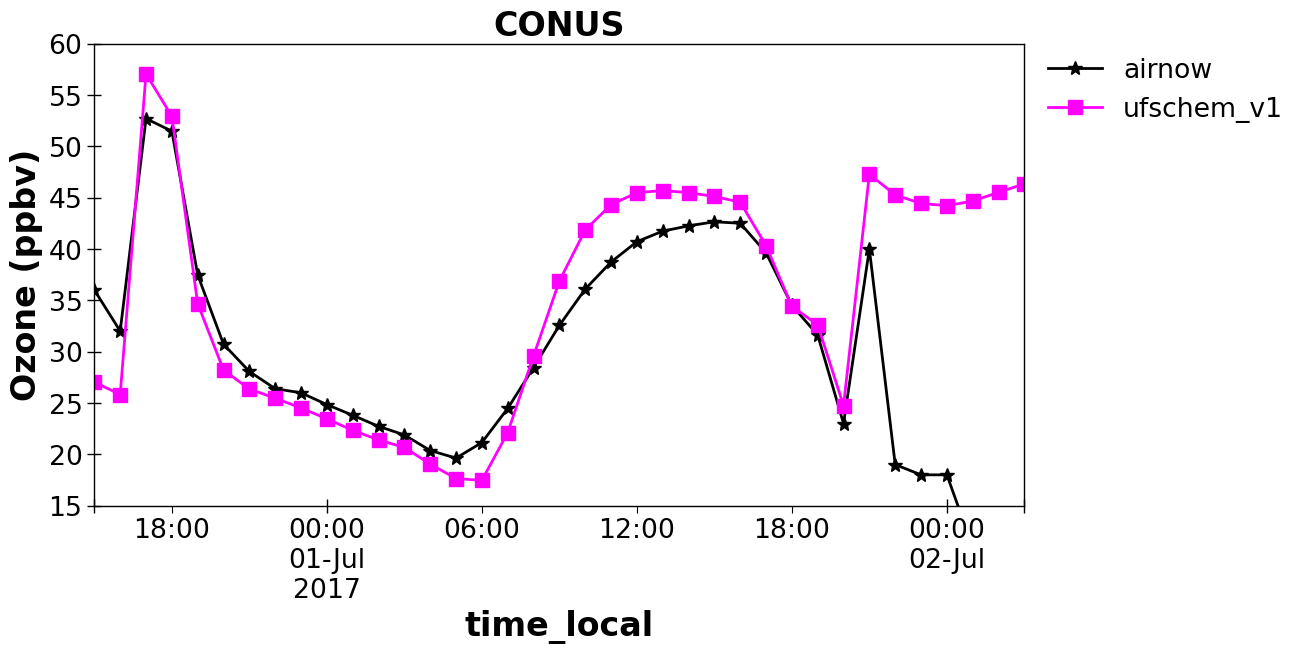

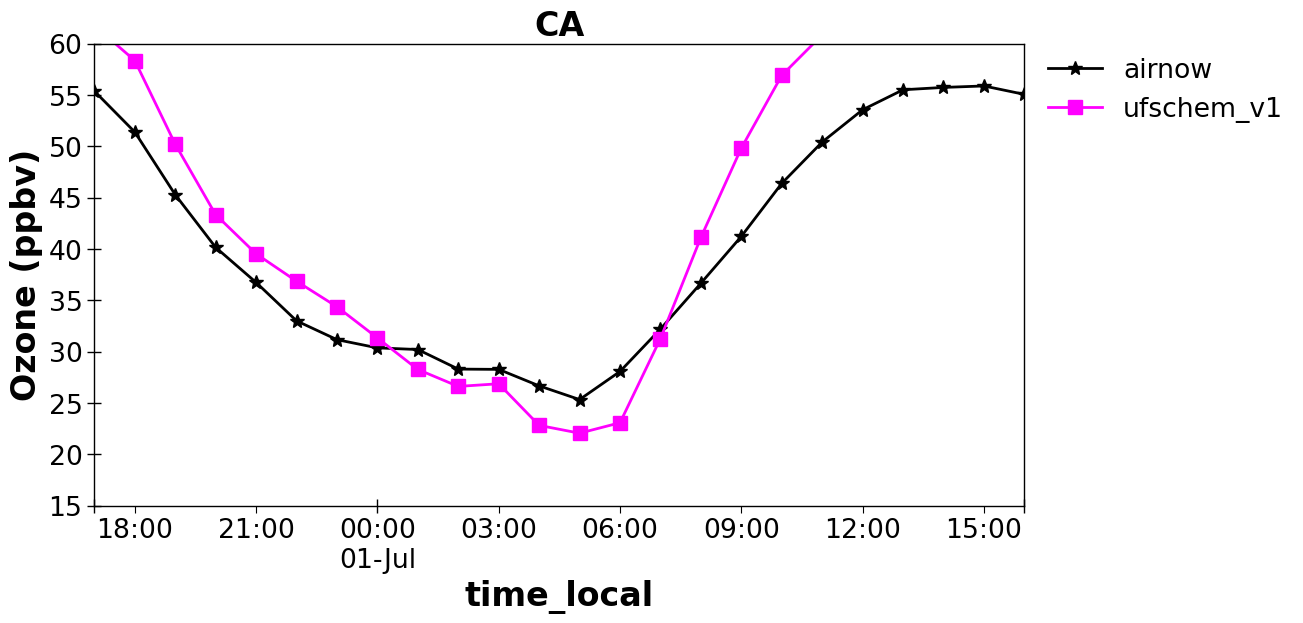

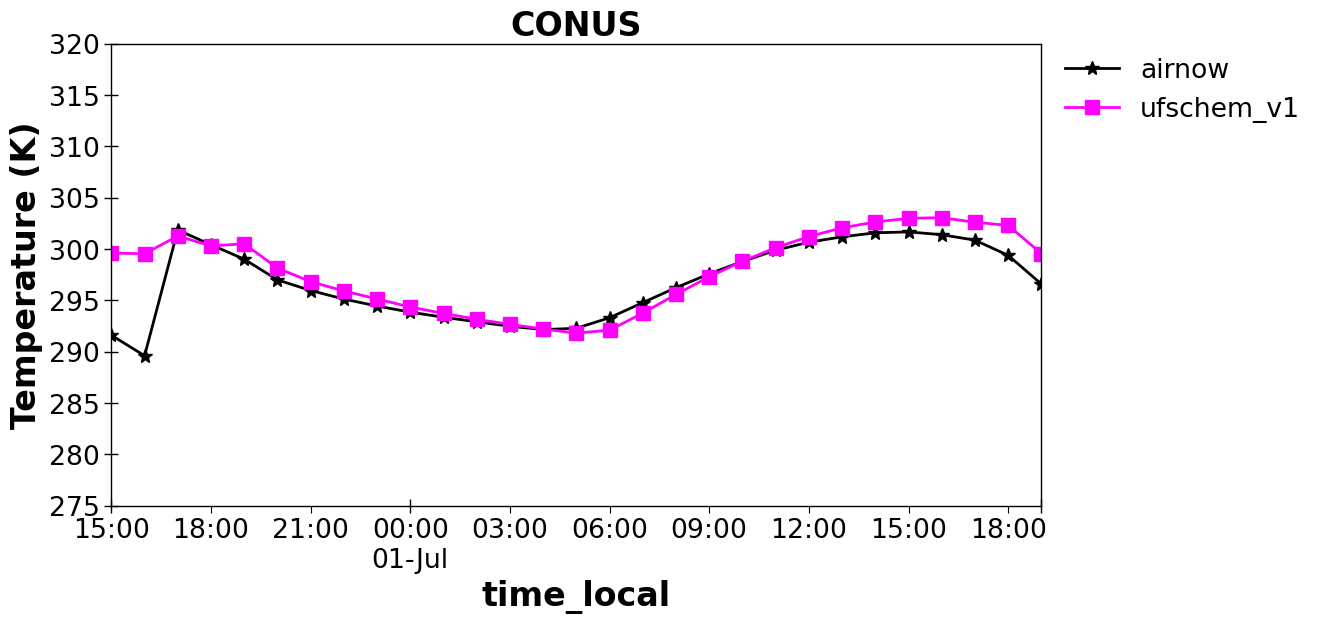

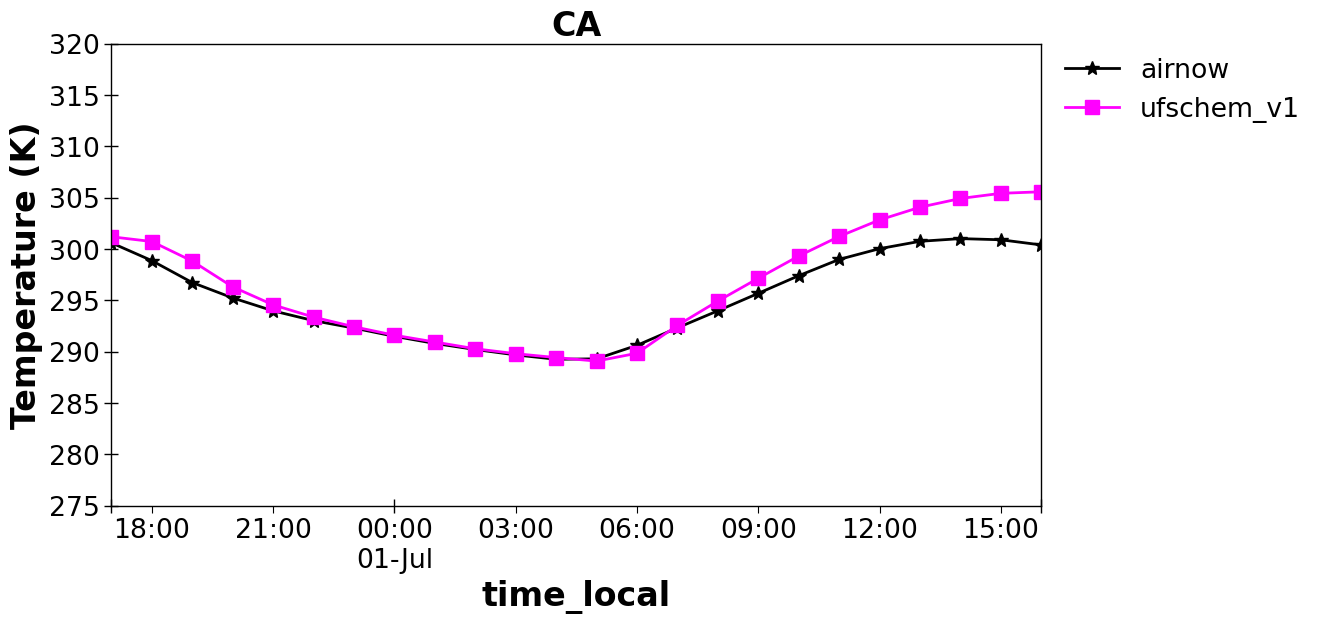

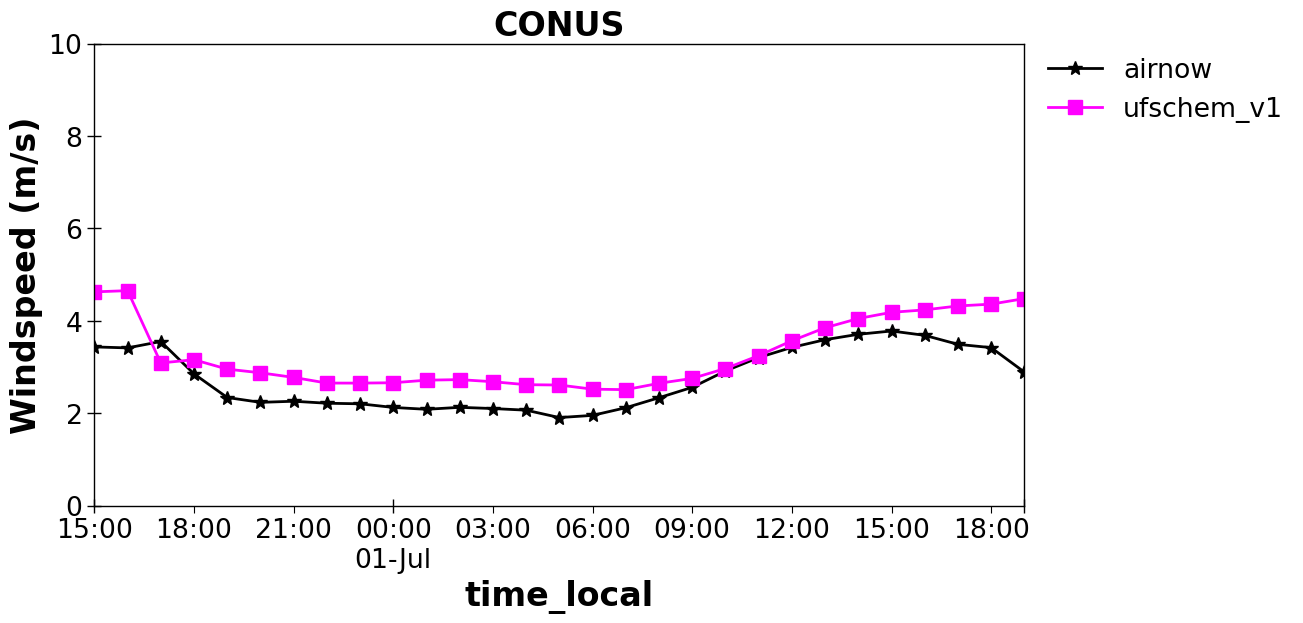

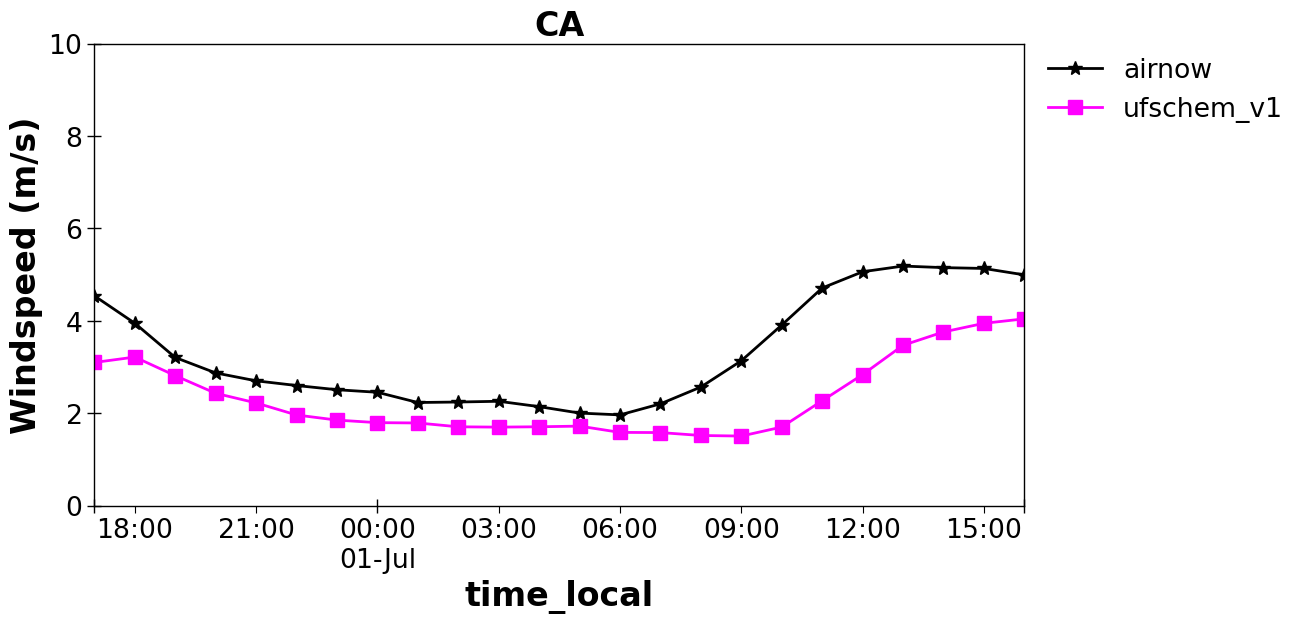

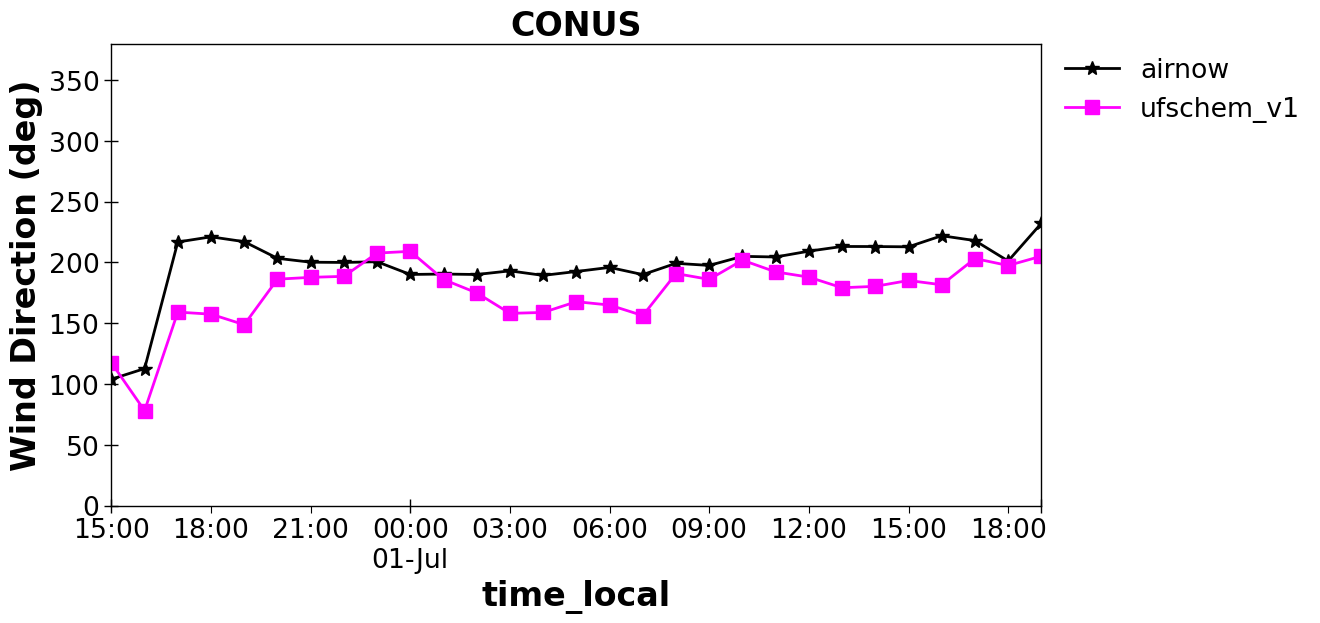

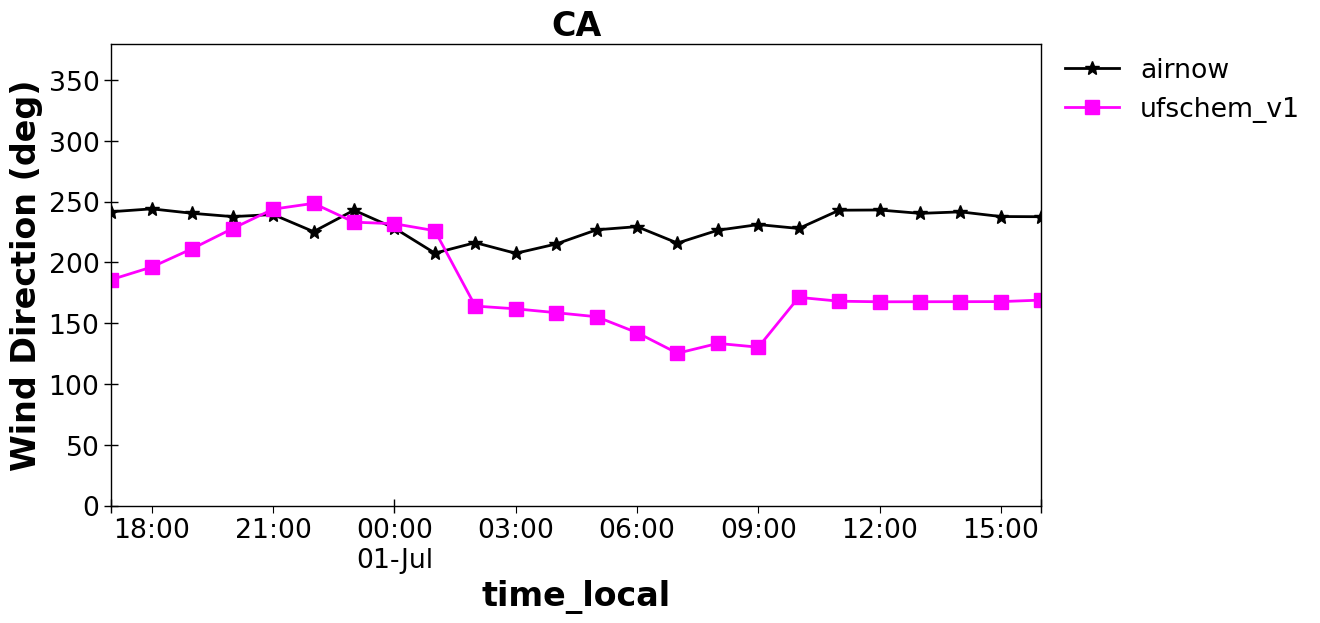

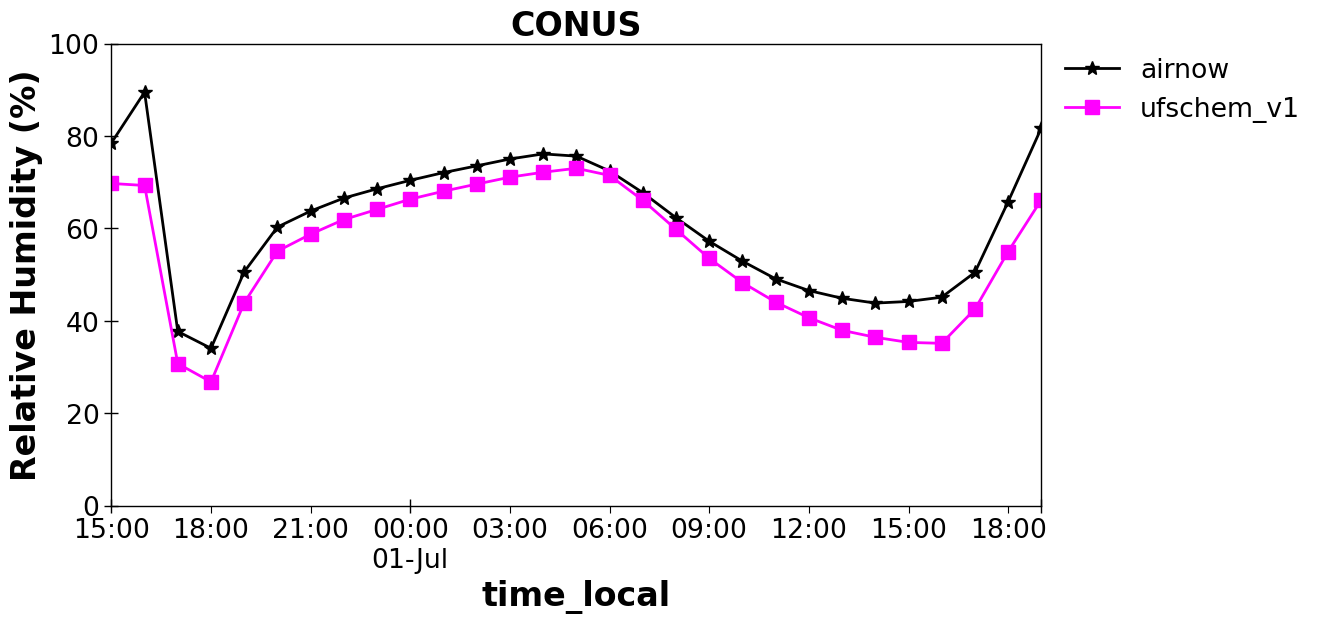

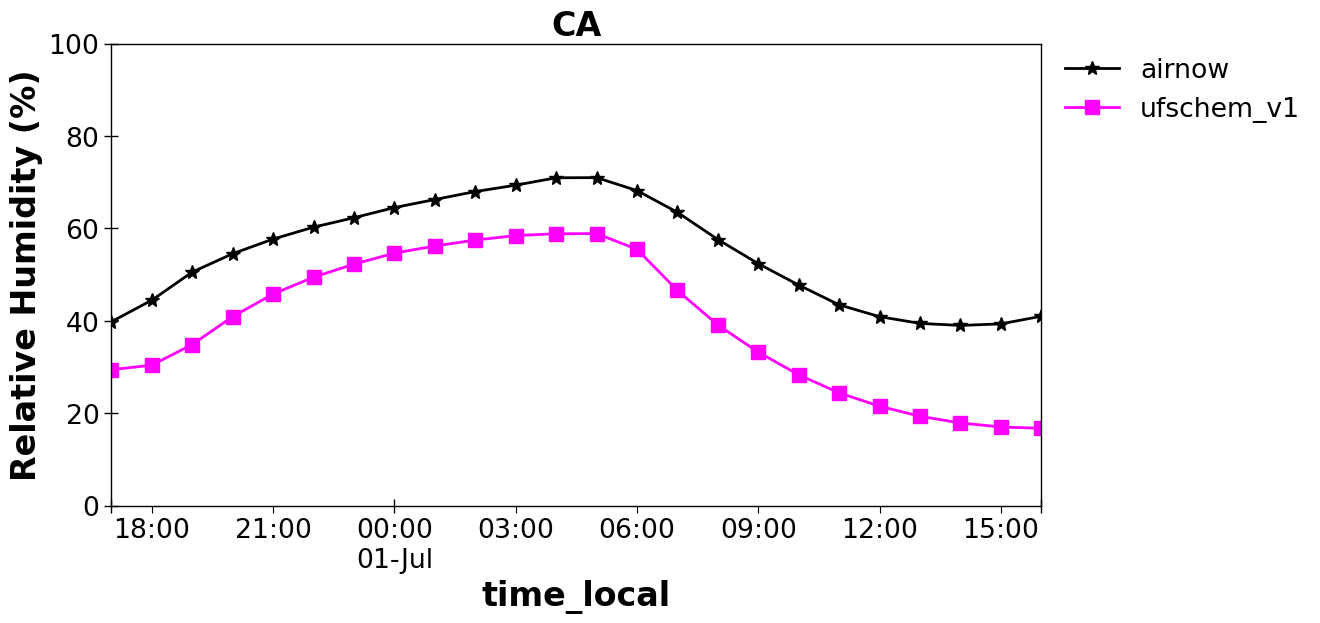

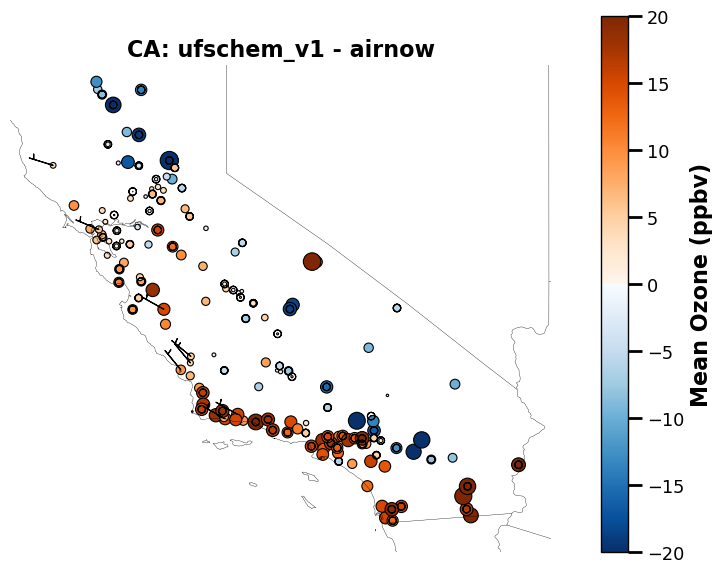

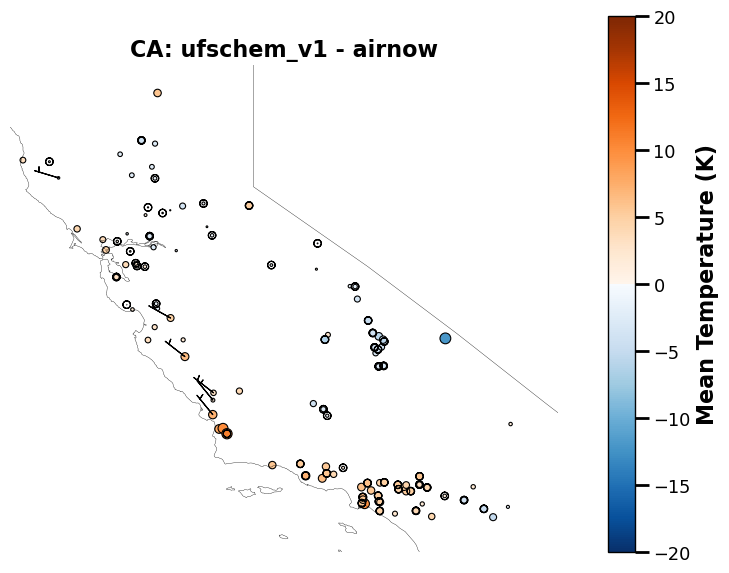

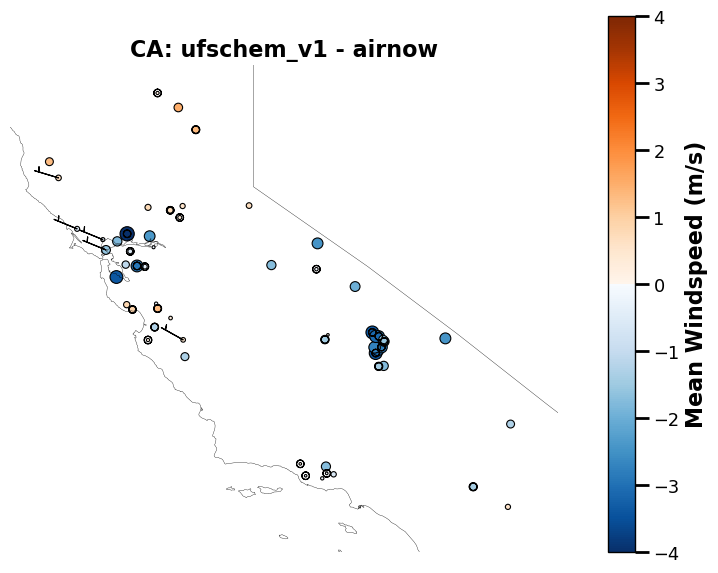

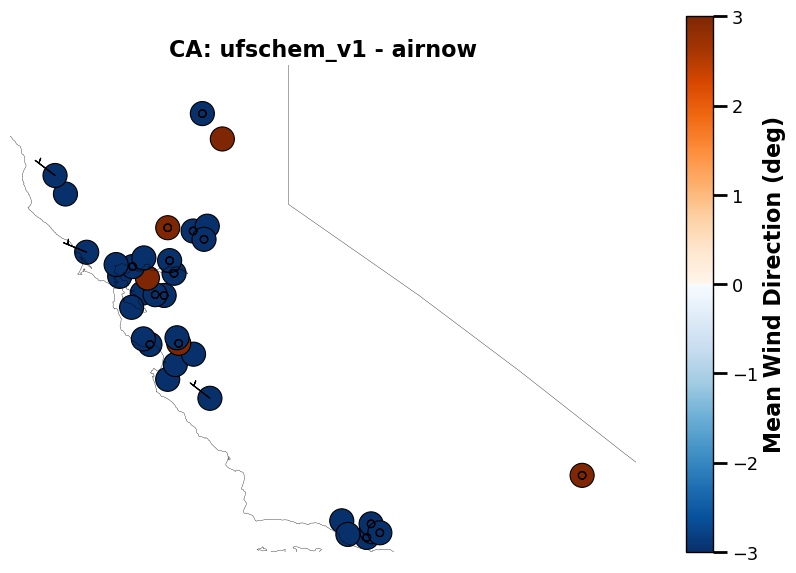

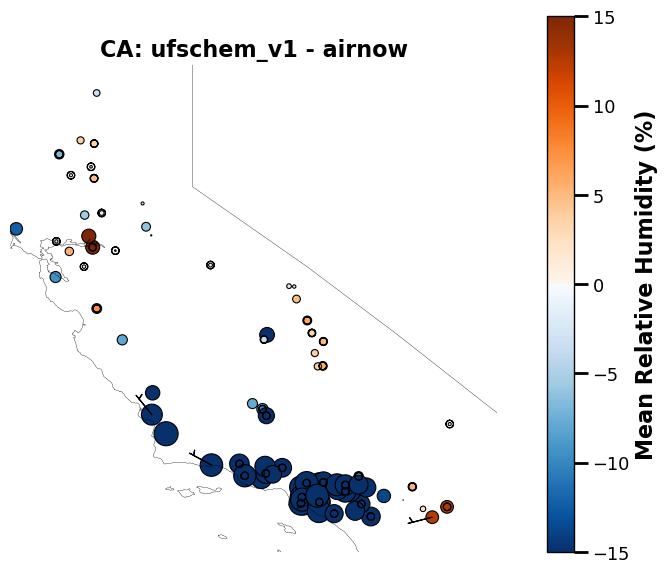

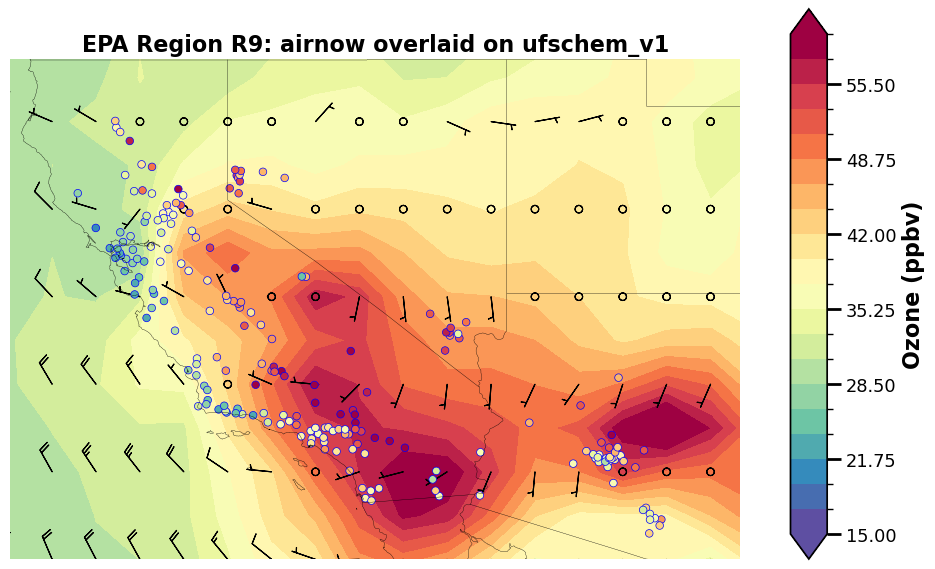

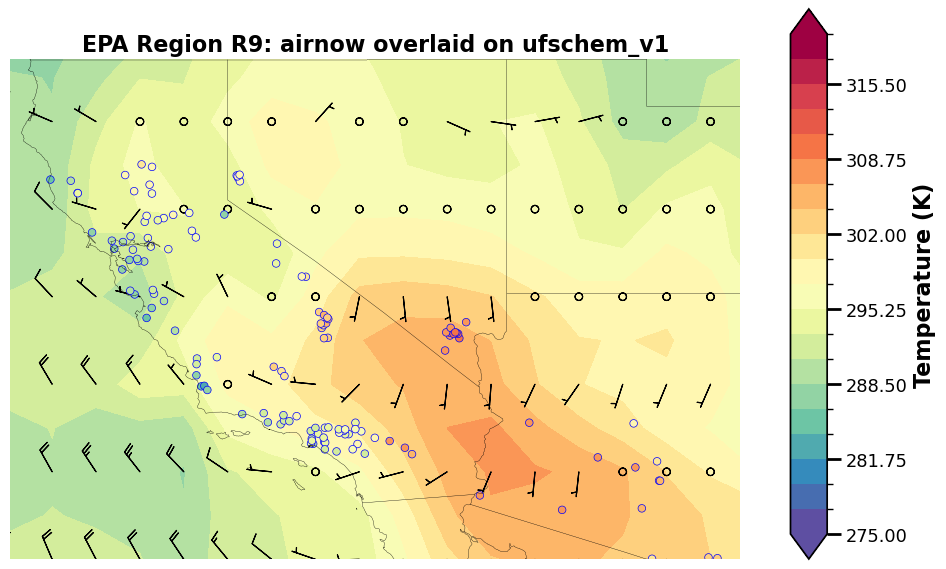

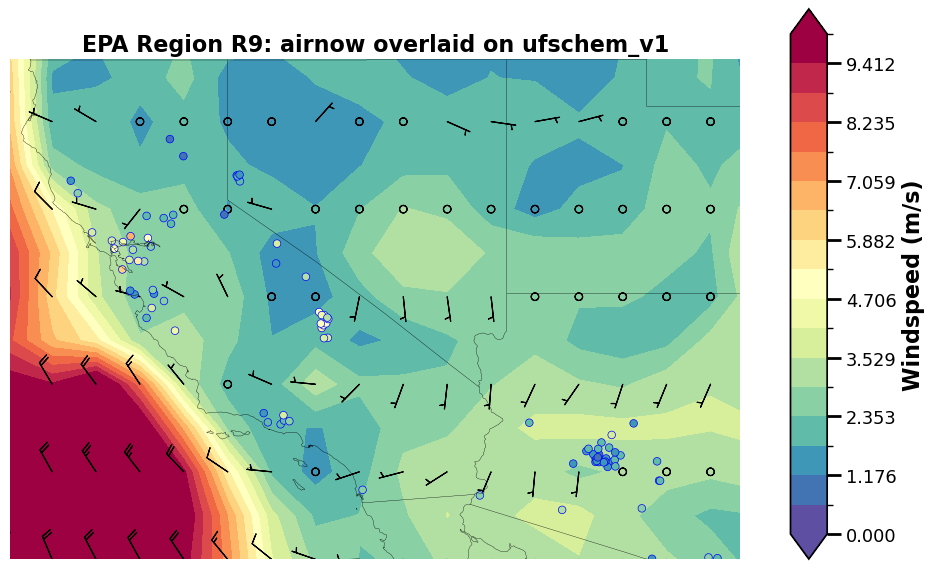

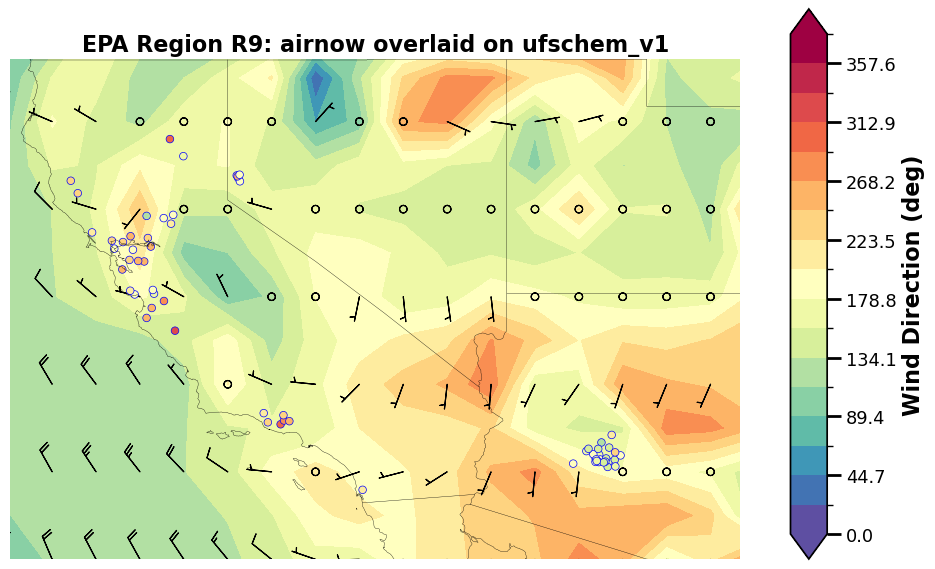

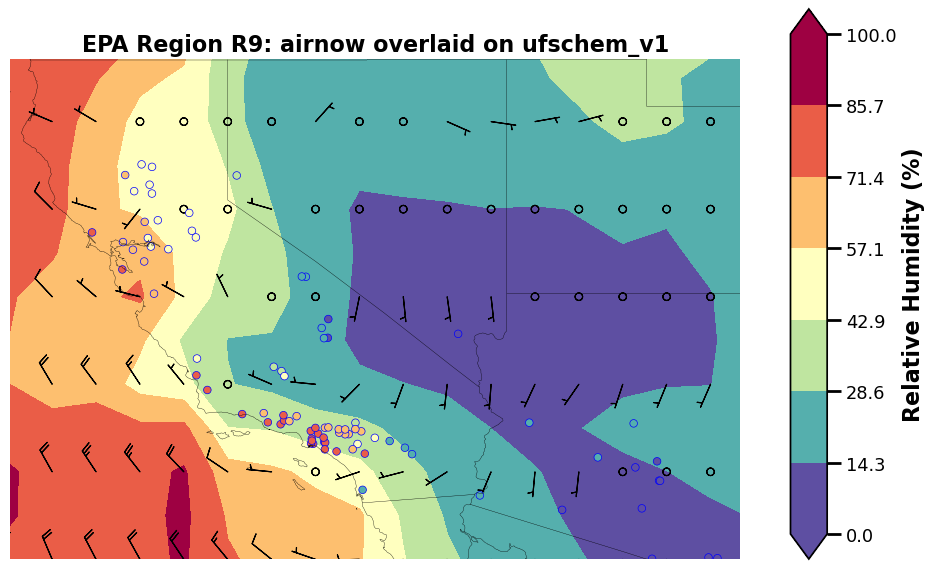

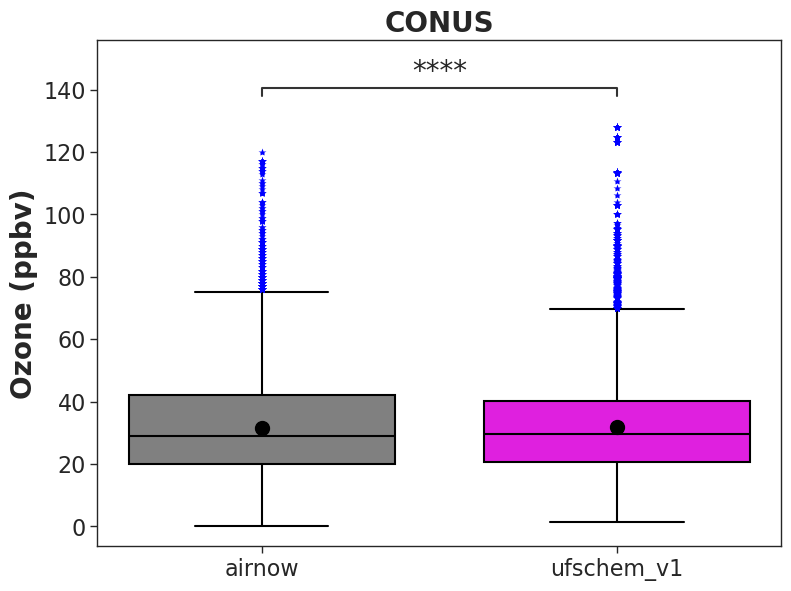

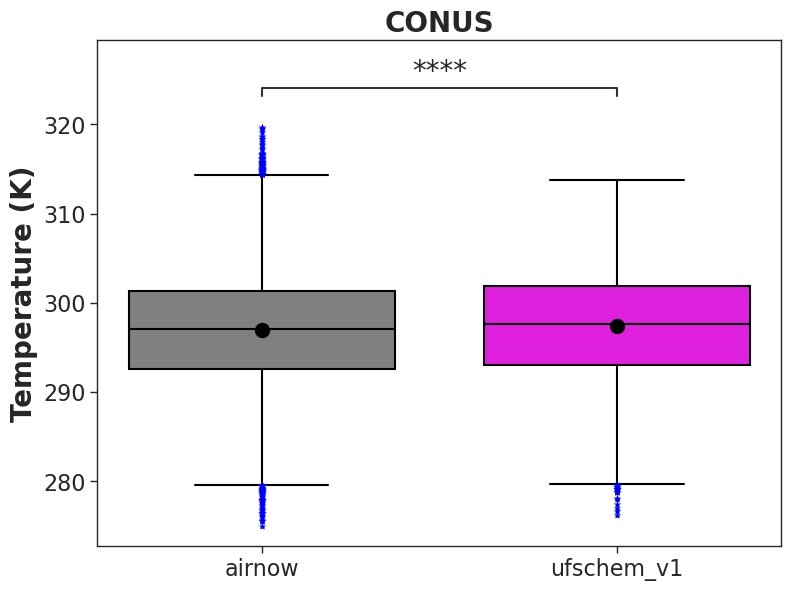

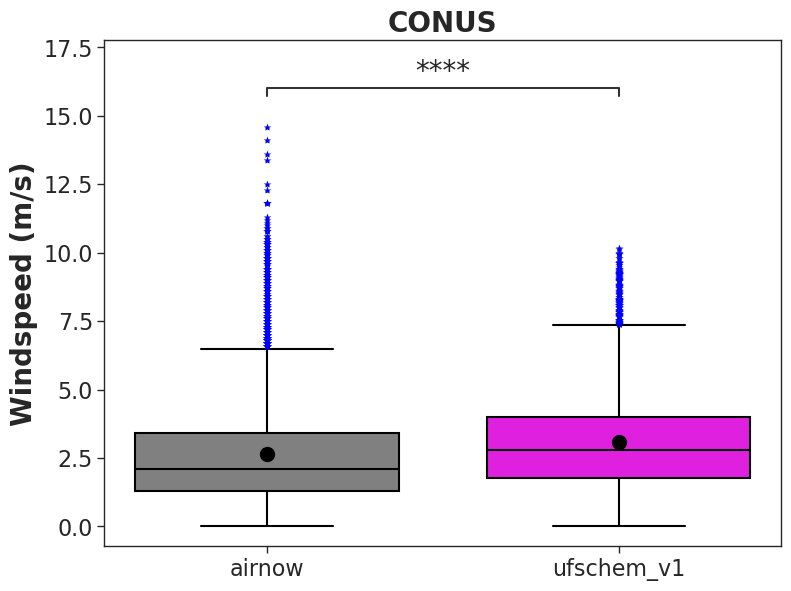

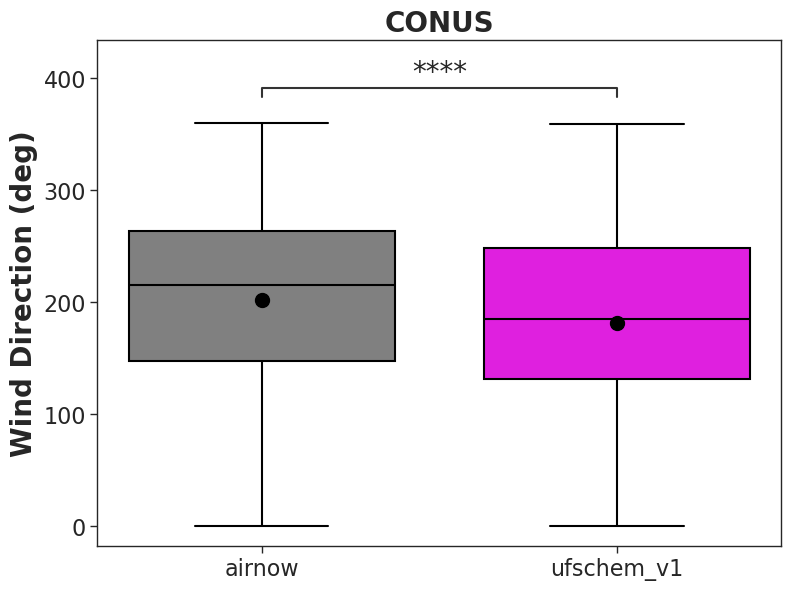

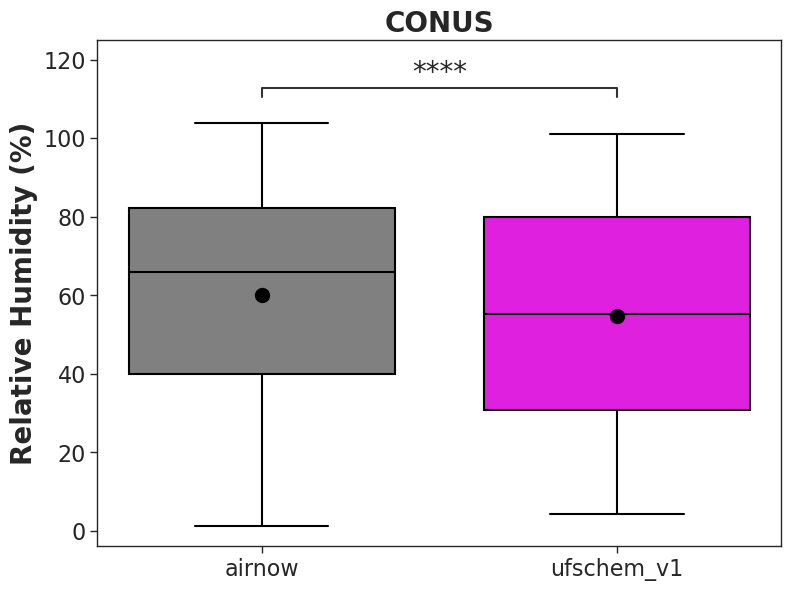

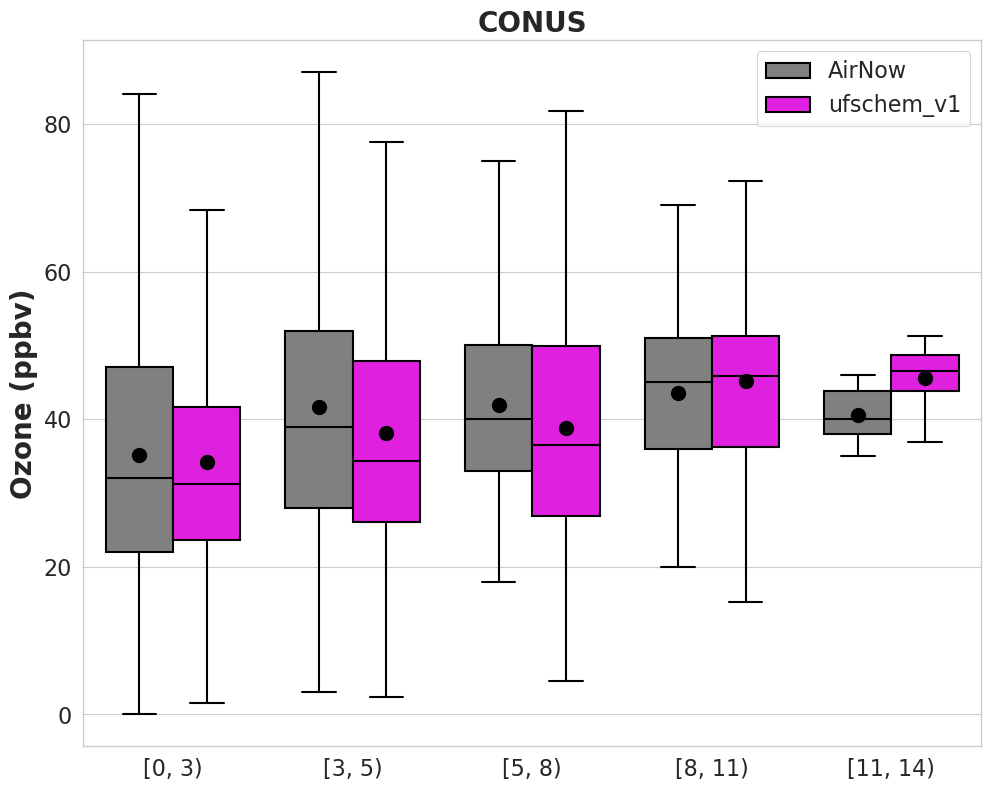

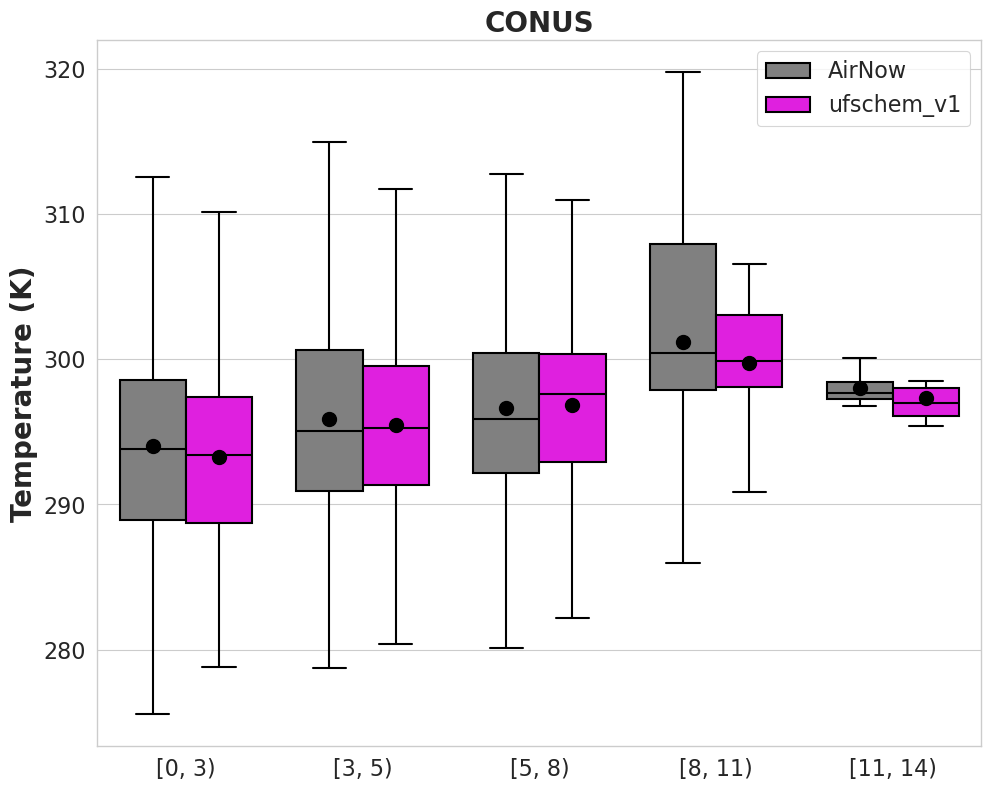

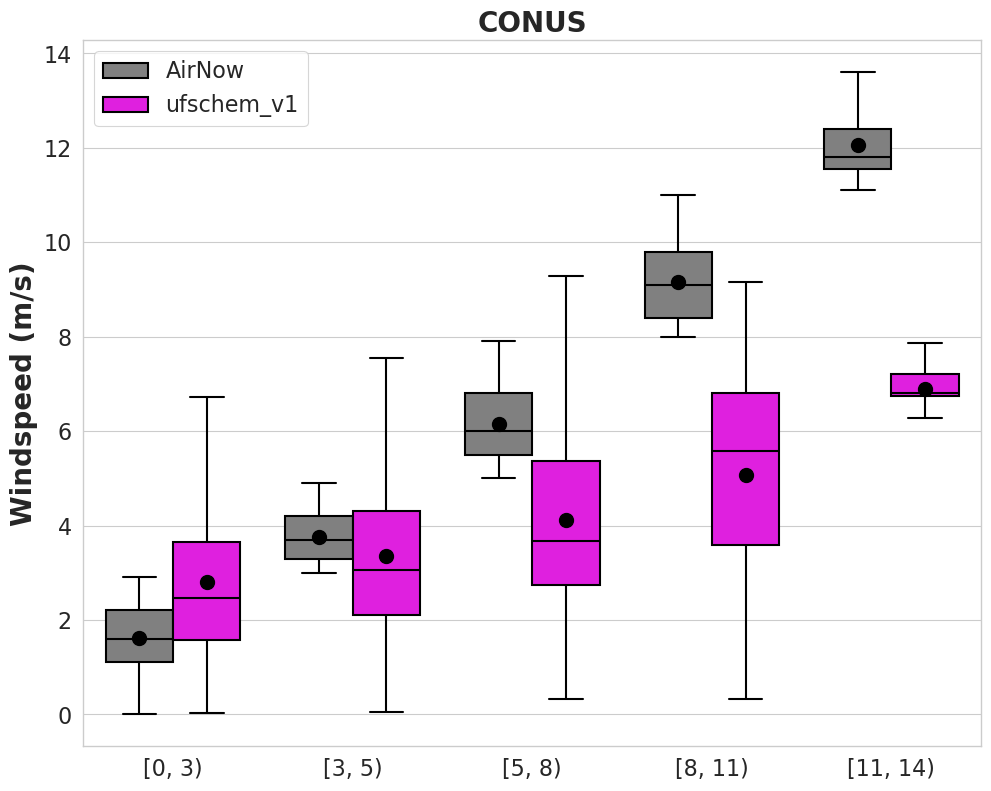

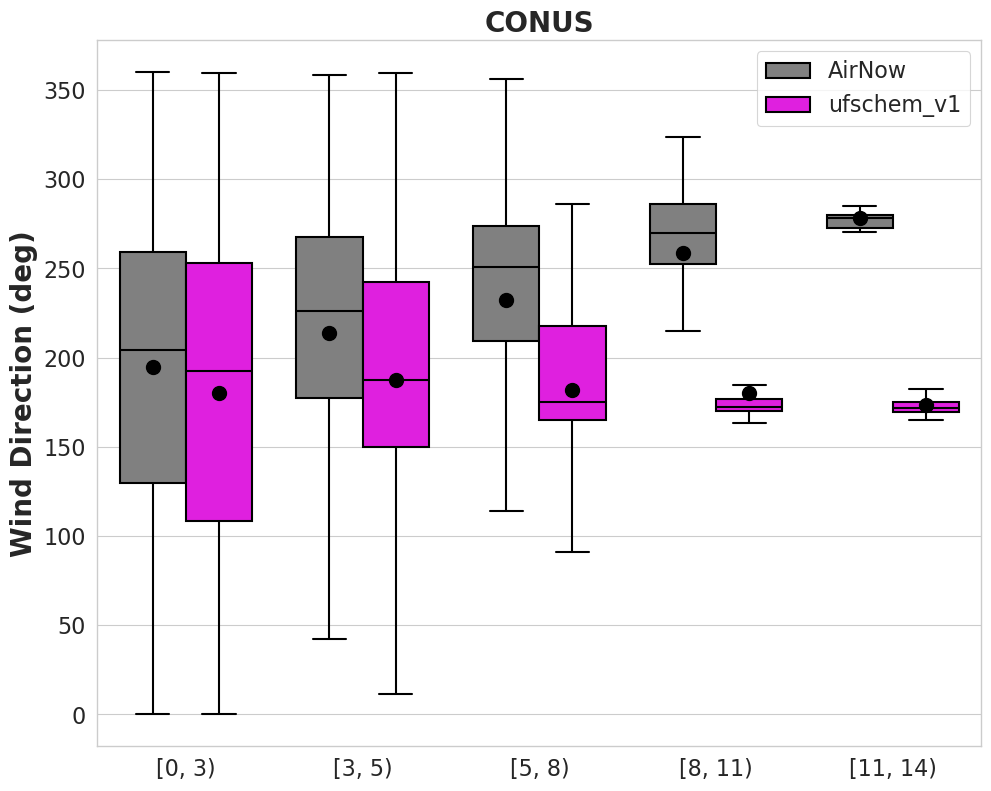

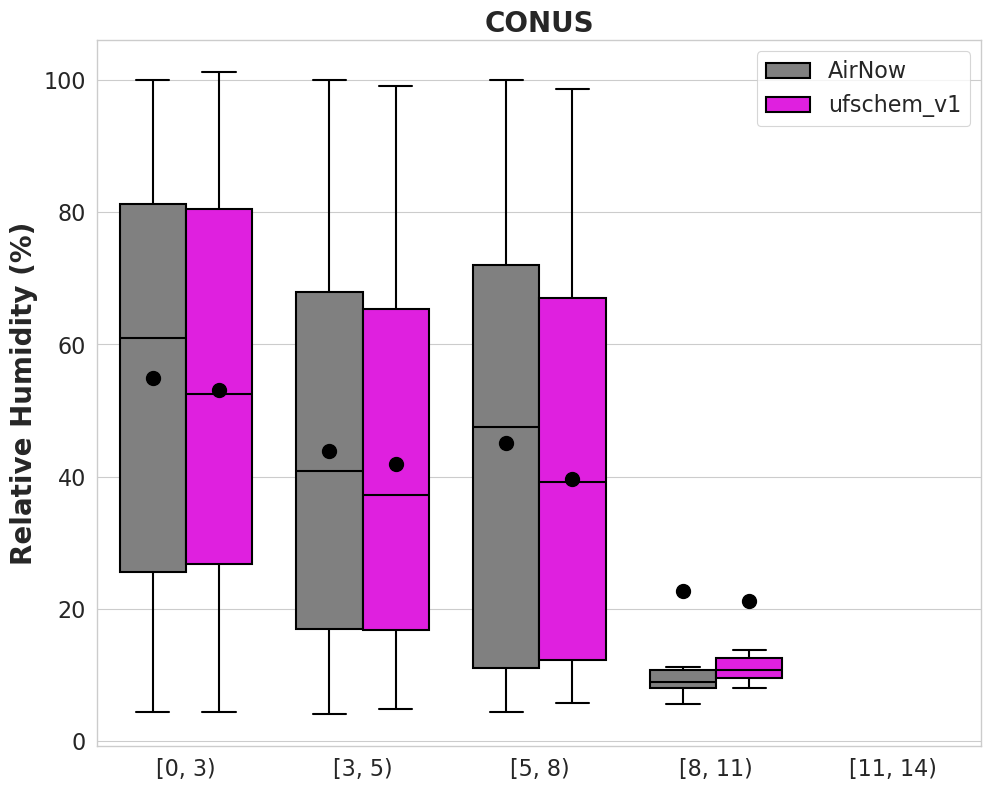

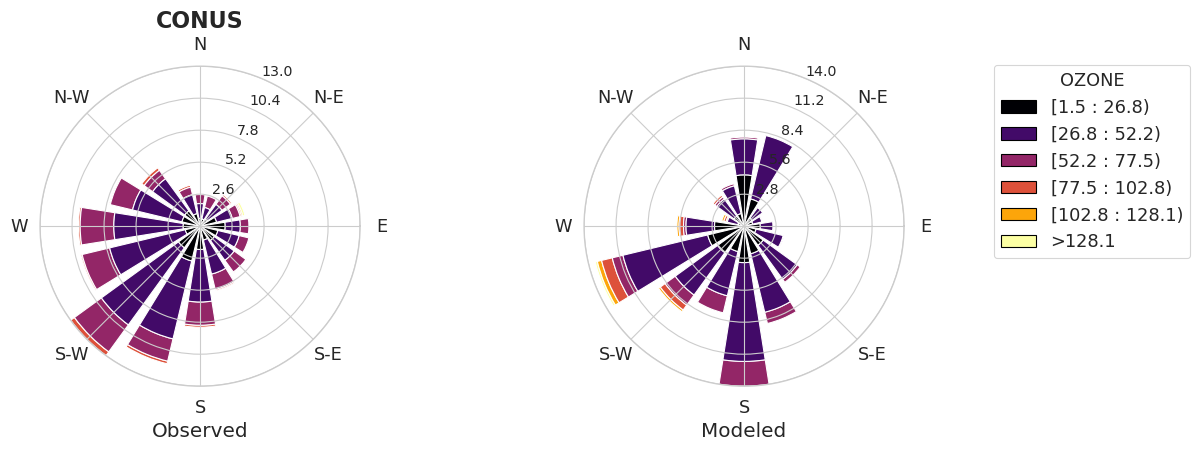

pairdf before: Index(['time', 'x', 'BARPR', 'BC', 'CO', 'NO', 'NO2', 'NO2Y', 'NOX', 'NOY',
       'OC', 'OZONE', 'PM10', 'PM2.5', 'PRECIP', 'RHUM', 'RWD', 'RWS', 'SO2',
       'SRAD', 'TEMP', 'UV-AETH', 'WD', 'WS', 'time_local', 'o3',
       'temperature_k', 'windspeed', 'winddir', 'rel_hum', 'spfh', 'ugrd',
       'vgrd', 'site', 'utcoffset', 'latitude', 'longitude', 'cmsa_name',
       'msa_code', 'msa_name', 'state_name', 'epa_region', 'siteid'],
      dtype='object')
Saving rose plot to ./output_img/ufschem/plot_grp6.rose_plot.TEMP.2017-07-01_00.2017-07-02_00.all.CONUS...


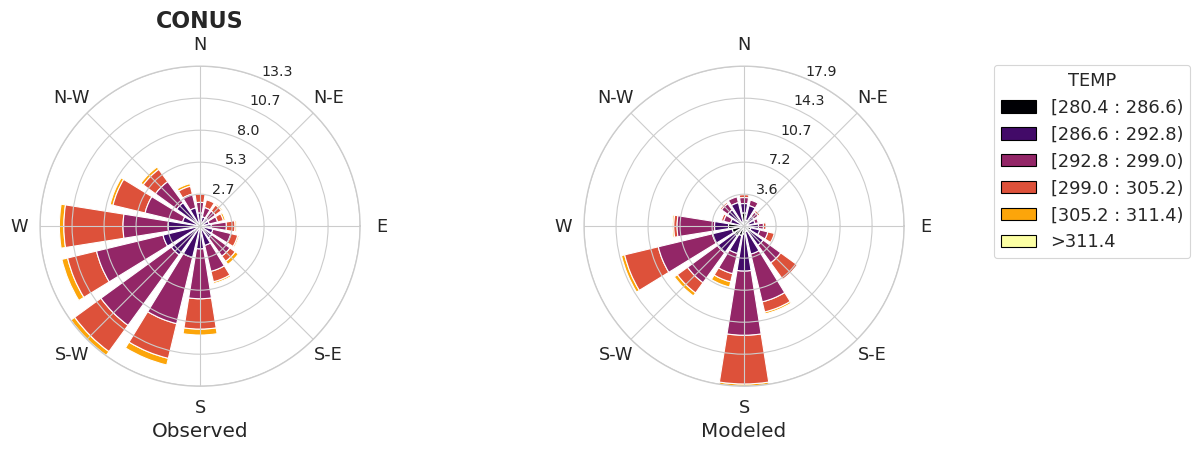

pairdf before: Index(['time', 'x', 'BARPR', 'BC', 'CO', 'NO', 'NO2', 'NO2Y', 'NOX', 'NOY',
       'OC', 'OZONE', 'PM10', 'PM2.5', 'PRECIP', 'RHUM', 'RWD', 'RWS', 'SO2',
       'SRAD', 'TEMP', 'UV-AETH', 'WD', 'WS', 'time_local', 'o3',
       'temperature_k', 'windspeed', 'winddir', 'rel_hum', 'spfh', 'ugrd',
       'vgrd', 'site', 'utcoffset', 'latitude', 'longitude', 'cmsa_name',
       'msa_code', 'msa_name', 'state_name', 'epa_region', 'siteid'],
      dtype='object')
Saving rose plot to ./output_img/ufschem/plot_grp6.rose_plot.WS.2017-07-01_00.2017-07-02_00.all.CONUS...


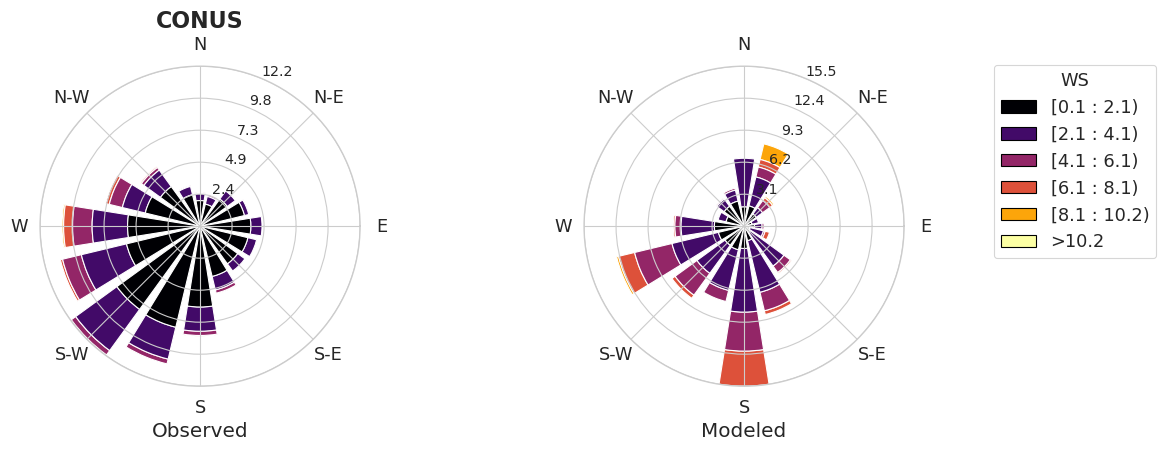

pairdf before: Index(['time', 'x', 'BARPR', 'BC', 'CO', 'NO', 'NO2', 'NO2Y', 'NOX', 'NOY',
       'OC', 'OZONE', 'PM10', 'PM2.5', 'PRECIP', 'RHUM', 'RWD', 'RWS', 'SO2',
       'SRAD', 'TEMP', 'UV-AETH', 'WD', 'WS', 'time_local', 'o3',
       'temperature_k', 'windspeed', 'winddir', 'rel_hum', 'spfh', 'ugrd',
       'vgrd', 'site', 'utcoffset', 'latitude', 'longitude', 'cmsa_name',
       'msa_code', 'msa_name', 'state_name', 'epa_region', 'siteid'],
      dtype='object')
Saving rose plot to ./output_img/ufschem/plot_grp6.rose_plot.WD.2017-07-01_00.2017-07-02_00.all.CONUS...


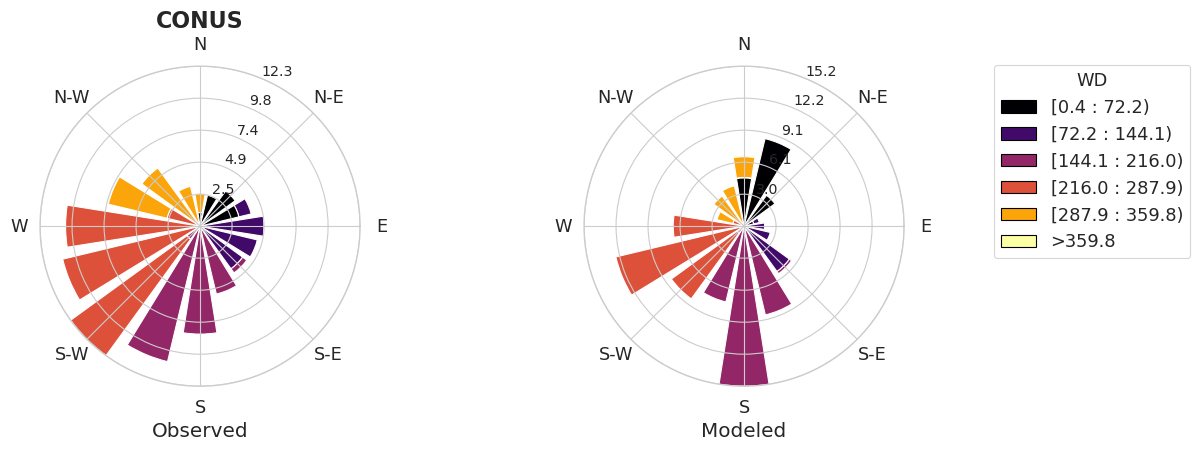

pairdf before: Index(['time', 'x', 'BARPR', 'BC', 'CO', 'NO', 'NO2', 'NO2Y', 'NOX', 'NOY',
       'OC', 'OZONE', 'PM10', 'PM2.5', 'PRECIP', 'RHUM', 'RWD', 'RWS', 'SO2',
       'SRAD', 'TEMP', 'UV-AETH', 'WD', 'WS', 'time_local', 'o3',
       'temperature_k', 'windspeed', 'winddir', 'rel_hum', 'spfh', 'ugrd',
       'vgrd', 'site', 'utcoffset', 'latitude', 'longitude', 'cmsa_name',
       'msa_code', 'msa_name', 'state_name', 'epa_region', 'siteid'],
      dtype='object')
Saving rose plot to ./output_img/ufschem/plot_grp6.rose_plot.RHUM.2017-07-01_00.2017-07-02_00.all.CONUS...


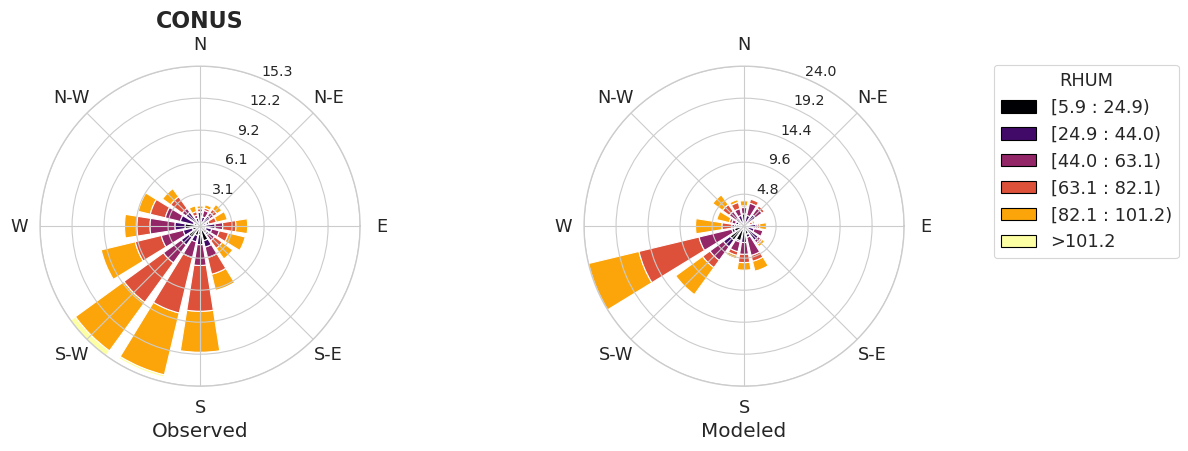

CPU times: user 1min 23s, sys: 2.06 s, total: 1min 25s
Wall time: 1min 24s


In [14]:
%%time

an.plotting()

In [15]:
%%time

an.stats()

CPU times: user 1.03 s, sys: 20 ms, total: 1.05 s
Wall time: 1.07 s


The stats routine has produced two files (one for each data variable).
This is one of them:
```{literalinclude} output/airnow_wrfchem/stats.OZONE.all.CONUS.2019-09-05_06.2019-09-06_06.csv
:caption:
```